In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

CSV = "Insert pull out testing (Antworten) - Formularantworten 1.csv"

df = pd.read_csv(CSV, usecols=range(6))
df.columns = ['timestamp', 'walls', 'density', 'torque', 'draft_angle', 'insert_length']
df['torque'] = pd.to_numeric(df['torque'], errors='coerce')
df['insert_length'] = df['insert_length'].str.strip()

# 4mm/15% angles 6-10 excluded — no 30% counterpart, trend already clear from 1-5
df = df[~((df['insert_length'] == '4mm') & (df['density'] == 15) & (df['draft_angle'] > 5))]
# 5.7mm/15%/wall=2 excluded — printed at 0.2mm layer height instead of 0.12mm
df = df[~((df['insert_length'] == '5.7mm') & (df['density'] == 15) & (df['walls'] == 2))]

print(df.groupby(['insert_length', 'density', 'walls'])['draft_angle'].count().to_string())
print(f"\ntorque range: {df['torque'].min()} – {df['torque'].max()}")

insert_length  density  walls
4mm            15       2        3
                        3        5
                        4        5
                        5        5
               30       2        5
                        3        5
                        4        5
                        5        5
5.7mm          15       4        4
                        5        4
               30       4        4
                        5        4

torque range: 3.0 – 6.0


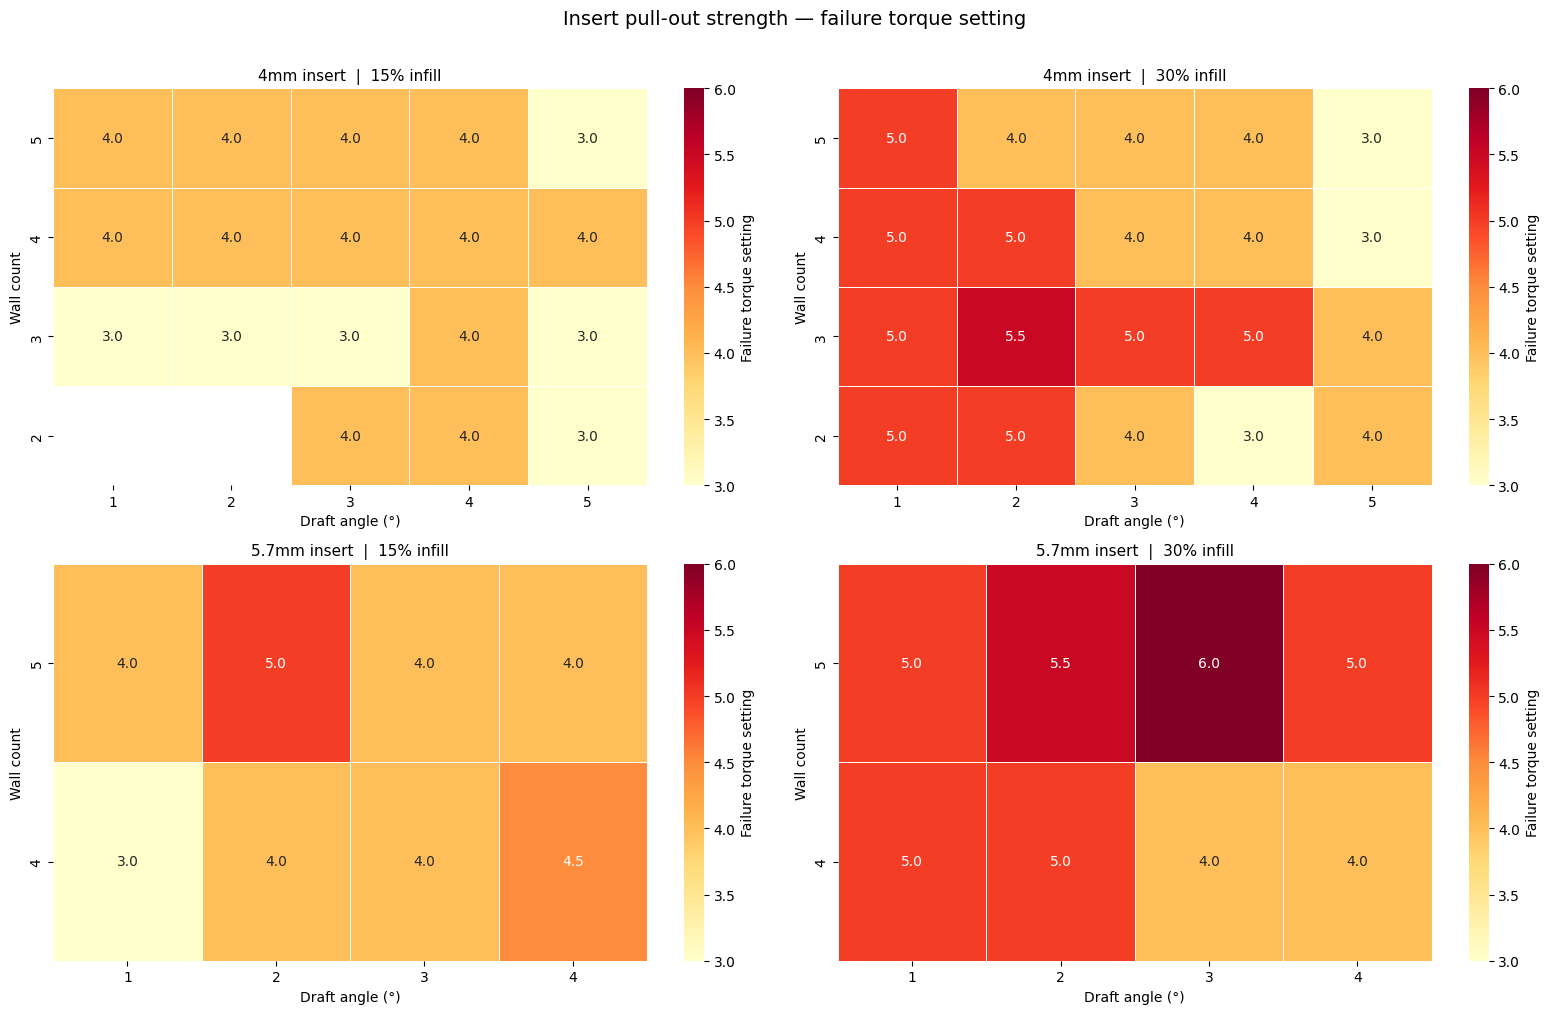

In [3]:
COMBOS = [
    ('4mm',   15, 0, 0),
    ('4mm',   30, 0, 1),
    ('5.7mm', 15, 1, 0),
    ('5.7mm', 30, 1, 1),
]

vmin = df['torque'].min()
vmax = df['torque'].max()
cmap = 'YlOrRd'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Insert pull-out strength — failure torque setting', fontsize=14, y=1.01)

for insert, density, row, col in COMBOS:
    ax = axes[row][col]
    subset = df[(df['insert_length'] == insert) & (df['density'] == density)]

    pivot = subset.pivot_table(
        index='walls', columns='draft_angle', values='torque', aggfunc='mean'
    ).sort_index(ascending=False)  # high wall count at top

    # annotation: show value or '–' for missing
    annot = pivot.copy().astype(object)
    for r in annot.index:
        for c in annot.columns:
            v = pivot.loc[r, c]
            annot.loc[r, c] = f'{v:.1f}' if not np.isnan(v) else '–'

    sns.heatmap(
        pivot,
        ax=ax,
        annot=annot,
        fmt='',
        vmin=vmin, vmax=vmax,
        cmap=cmap,
        mask=pivot.isna(),
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': 'Failure torque setting'},
    )
    ax.set_title(f'{insert} insert  |  {density}% infill', fontsize=11)
    ax.set_xlabel('Draft angle (°)')
    ax.set_ylabel('Wall count')

plt.tight_layout()
plt.savefig('insert_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

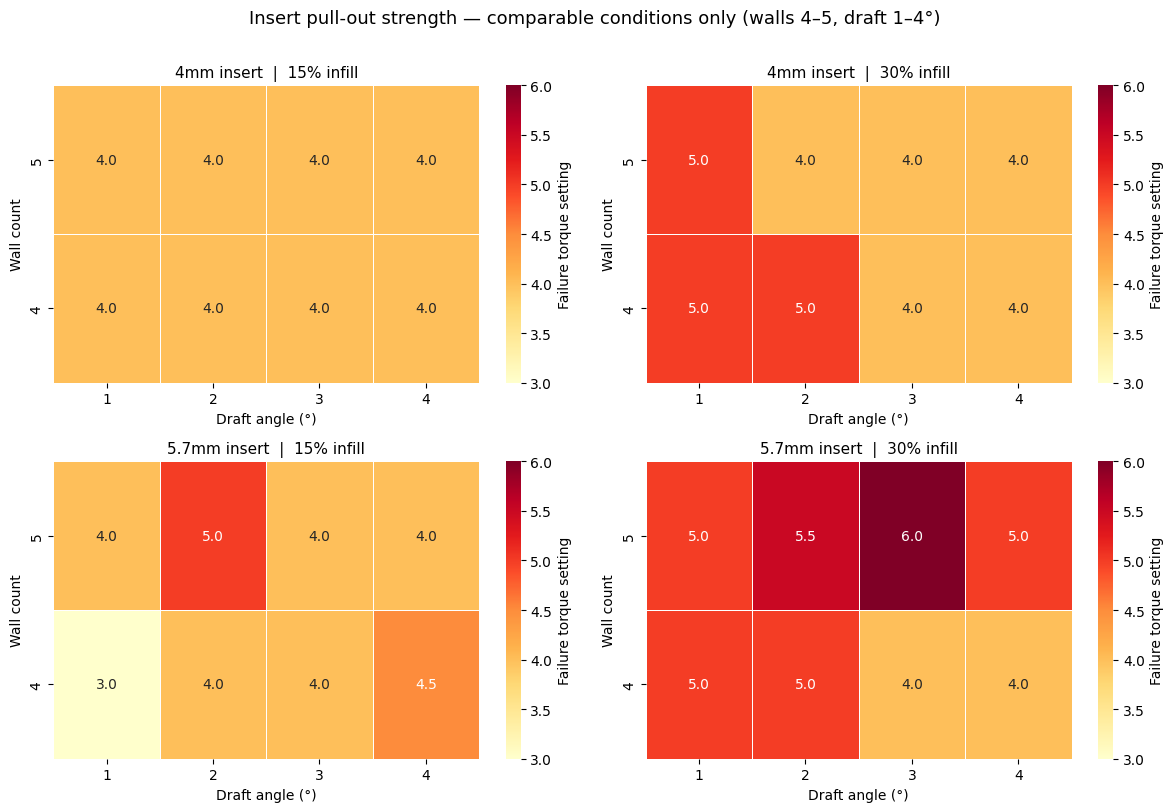

In [4]:
# Comparable subset: only conditions present in both insert lengths
# Drops 4mm-only: draft angle 5, wall counts 2 and 3
df_cmp = df[df['draft_angle'] <= 4]
df_cmp = df_cmp[df_cmp['walls'].isin([4, 5])]

COMBOS_CMP = [
    ('4mm',   15, 0, 0),
    ('4mm',   30, 0, 1),
    ('5.7mm', 15, 1, 0),
    ('5.7mm', 30, 1, 1),
]

vmin_c = df_cmp['torque'].min()
vmax_c = df_cmp['torque'].max()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Insert pull-out strength — comparable conditions only (walls 4–5, draft 1–4°)', fontsize=13, y=1.01)

for insert, density, row, col in COMBOS_CMP:
    ax = axes[row][col]
    subset = df_cmp[(df_cmp['insert_length'] == insert) & (df_cmp['density'] == density)]

    pivot = subset.pivot_table(
        index='walls', columns='draft_angle', values='torque', aggfunc='mean'
    ).sort_index(ascending=False)

    annot = pivot.copy().astype(object)
    for r in annot.index:
        for c in annot.columns:
            v = pivot.loc[r, c]
            annot.loc[r, c] = f'{v:.1f}' if not np.isnan(v) else '–'

    sns.heatmap(
        pivot,
        ax=ax,
        annot=annot,
        fmt='',
        vmin=vmin_c, vmax=vmax_c,
        cmap='YlOrRd',
        mask=pivot.isna(),
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': 'Failure torque setting'},
    )
    ax.set_title(f'{insert} insert  |  {density}% infill', fontsize=11)
    ax.set_xlabel('Draft angle (°)')
    ax.set_ylabel('Wall count')

plt.tight_layout()
plt.savefig('insert_heatmaps_comparable.png', dpi=150, bbox_inches='tight')
plt.show()